In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.io as sp # for reading MatLab binary files
import mat73
from parse_centroids import centroid_dataframe as cd
from parse_ids import ids_dataframe as idf
from id_arr_generator import id_array_generator as iag
from plot_id_arr import plot_id_array as pia
from langley import langley_plot

1) Read the MatLab data output from `run_match_stars.m`.
- `centroids` is 360(frames) x (?)(# of data), each with a sub-array for each centroid.
- `ids` is 360(frames) x (?)(# of data), each with a sub-array for each star ID.
- `rads` is 360(frames) x 1100 x 1600; this is the "radiance stack" representing the radiances for each frame. Potentially useful for plotting.

In [ ]:
# Read the MatLab files
fdir = "/Users/jacksontobin/Local_Documents/NightTime_Research/ANGSTROM/Star_Photometry/Angstrom3_ColState/Angstrom_Overnight_2025_10_27_050000_060000/Band_450nm_BFS-PGE-16S7M_SN22245818/"
centroid_name = "Band_450nm_BFS-PGE-16S7M_SN22245818_centroids.mat"
radiance_name = "Band_450nm_BFS-PGE-16S7M_SN22245818_Radiance.mat"
starid_name = "Band_450nm_BFS-PGE-16S7M_SN22245818_StarID.mat"

stars = idf(fdir + starid_name)
centroids = cd(fdir + centroid_name)

,frame,hr,x,y,el,az,mag,ra,dec,area,...,diameter,total_DN,Az,El,Name,Mag,RA,Dec,HR,utc_dtime
0,NaN,"[5744, 5886, 5960, 5986, 6025, 6126, 6127, 613...","[[1211.4117647058824], [1203.111111111111], [7...","[[915.8823529411765], [609.6666666666666], [96...","[[16.174255904954734], [20.66971785126086], [1...","[[337.871057434159], [337.86434922245417], [33...","[[3.29], [5.19], [4.96], [4.01], [5.44], [5.26...","[[231.23241000000002], [236.66658], [239.44794...","[[58.966065], [62.599557], [54.749762], [58.56...","[[17], [9], [10], [14], [7], [4], [5], [21], [...",...,"[[4.7559631624854735], [3.539114962373918], [3...","[[2.3779815812427367], [1.769557481186959], [1...",[[360]],"[[5986], [6130], [6132], [6237], [6315], [6369...","[[1379.3125], [1313.6], [1313.6], [976.375], [...","[[1041.875], [772.4], [772.4], [931.25], [429....","[[1362.758404623365], [1309.0333725864562], [1...","[[1036.989150439477], [763.0611141085853], [77...","[[14.270331026236418], [18.363697258581805], [...","[[4.01], [5.67], [2.73], [4.84], [4.88], [4.91..."
1,NaN,"[5744, 5878, 5886, 5887, 5960, 5986, 6025, 612...","[[1212.5625], [899.75], [1203.875], [899.75], ...","[[916.25], [996.0], [610.125], [996.0], [967.2...","[[16.162308088593928], [15.01096035808218], [2...","[[337.88971937468267], [333.31394150010067], [...","[[3.29], [5.94], [5.19], [5.85], [4.96], [4.01...","[[231.23241000000002], [236.64505499999999], [...","[[58.966065], [55.474791], [62.599557], [55.37...","[[16], [4], [8], [4], [10], [16], [8], [4], [7...",...,"[[4.643789211774307], [2.5683582313850133], [3...","[[2.3218946058871537], [1.2841791156925066], [...",[[360]],"[[5986], [6130], [6132], [6237], [6315], [6369...","[[1379.3125], [1313.6], [1313.6], [976.375], [...","[[1041.875], [772.4], [772.4], [931.25], [429....","[[1362.758404623365], [1309.0333725864562], [1...","[[1036.989150439477], [763.0611141085853], [77...","[[14.270331026236418], [18.363697258581805], [...","[[4.01], [5.67], [2.73], [4.84], [4.88], [4.91..."
2,NaN,"[5744, 5878, 5886, 5887, 5960, 5986, 6025, 612...","[[1214.1363636363637], [901.6], [1205.2], [901...","[[918.3636363636364], [997.8], [612.3], [997.8...","[[16.150370040410472], [14.996715249813295], [...","[[337.9083865299315], [333.3335263491166], [33...","[[3.29], [5.94], [5.19], [5.85], [4.96], [4.01...","[[231.23241000000002], [236.64505499999999], [...","[[58.966065], [55.474791], [62.599557], [55.37...","[[22], [5], [10], [5], [10], [17], [10], [7], ...",...,"[[5.490375187144627], [2.717860863863054], [3....","[[2.7451875935723136], [1.358930431931527], [1...",[[360]],"[[5986], [6130], [6132], [6237], [6315], [6369...","[[1379.3125], [1313.6], [1313.6], [976.375], [...","[[1041.875], [772.4], [772.4], [931.25], [429....","[[1362.758404623365], [1309.0333725864562], [1...","[[1036.989150439477], [763.0611141085853], [77...","[[14.270331026236418], [18.363697258581805], [...","[[4.01], [5.67], [2.73], [4.84], [4.88], [4.91..."
3,NaN,"[5744, 5878, 5886, 5887, 5960, 5986, 6025, 612...","[[1215.3333333333333], [902.6], [1206.125], [9...","[[919.0], [998.8], [612.875], [998.8], [970.5]...","[[16.13844152448373], [14.982479778195977], [2...","[[337.9270592710408], [333.353117525746], [337...","[[3.29], [5.94], [5.19], [5.85], [4.96], [4.01...","[[231.23241000000002], [236.64505499999999], [...","[[58.966065], [55.474791], [62.599557], [55.37...","[[18], [5], [8], [5], [10], [15], [9], [4], [5...",...,"[[4.914263765391484], [2.717860863863054], [3....","[[2.457131882695742], [1.358930431931527], [1....",[[360]],"[[5986], [6130], [6132], [6237], [6315], [6369...","[[1379.3125], [1313.6], [1313.6], [976.375], [...","[[1041.875], [772.4], [772.4], [931.25], [429....","[[1362.758404623365], [1309.0333725864562], [1...","[[1036.989150439477], [763.0611141085853], [77...","[[14.270331026236418], [18.363697258581805], [...","[[4.01], [5.67], [2.73], [4.84], [4.88], [4.91..."
4,NaN,"[5744, 5886, 5960, 5986, 6025, 6127, 6130, 613...","[[1216.388888888889], [1207.2], 

2. Create the ID Array for easy plotting.

In [3]:
id_arr = iag(stars)

3. Plot the raw DN for a sanity check. We expect the DN to decrease for each star throughout the hour.

RangeIndex(start=0, stop=360, step=1)


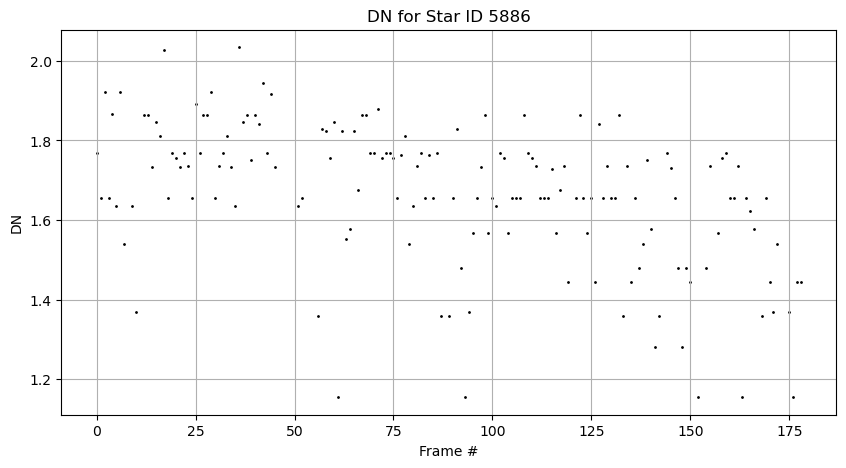

In [ ]:
# star_id = 6130
# star_id = 6170 # number discritization near ~1.0
star_id = 5886
id_arr_star = id_arr[star_id]
plt.figure(figsize=(10, 5))
x = id_arr_star.index
print(x)
# y is the 2nd value in each entry of id_arr_star
y = []
for entry in id_arr_star:
    if isinstance(entry, tuple):
        y.append(entry[1])
    else:
        y.append(np.nan)
y = np.array(y)
# y = np.array([entry[1] for entry in id_arr_star])
plt.scatter(x, y, s=1, c='black')
plt.title(f"DN for Star ID {star_id}")
plt.xlabel("Frame #")
plt.ylabel("DN")
plt.grid()
plt.show()


4. Plot the ID Array

0      73.825744
1      73.837692
2      73.849630
3      73.861558
4      73.873478
         ...    
355          NaN
356          NaN
357          NaN
358          NaN
359          NaN
Name: 5744, Length: 360, dtype: float64 0      1.288502
1      1.288711
2      1.288919
3      1.289127
4      1.289335
         ...   
355         NaN
356         NaN
357         NaN
358         NaN
359         NaN
Name: 5744, Length: 360, dtype: float64
0      69.330282
1      69.342234
2      69.354178
3      69.366113
4      69.378040
         ...    
355          NaN
356          NaN
357          NaN
358          NaN
359          NaN
Name: 5886, Length: 360, dtype: float64 0      1.210042
1      1.210250
2      1.210459
3      1.210667
4      1.210875
         ...   
355         NaN
356         NaN
357         NaN
358         NaN
359         NaN
Name: 5886, Length: 360, dtype: float64
0      74.560725
1      74.575850
2      74.590965
3      74.606071
4      74.621167
         ...    
355         

/Users/jacksontobin/Local_Documents/coding_shenanigans/ANGSTROM/langley.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  els  = dataframe.applymap(lambda x: x[3] if isinstance(x, tuple) else np.nan)
/Users/jacksontobin/Local_Documents/coding_shenanigans/ANGSTROM/langley.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  area = dataframe.applymap(lambda x: x[2] if isinstance(x, tuple) else np.nan)
/Users/jacksontobin/Local_Documents/coding_shenanigans/ANGSTROM/langley.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dns  = dataframe.applymap(lambda x: x[1] if isinstance(x, tuple) else np.nan)


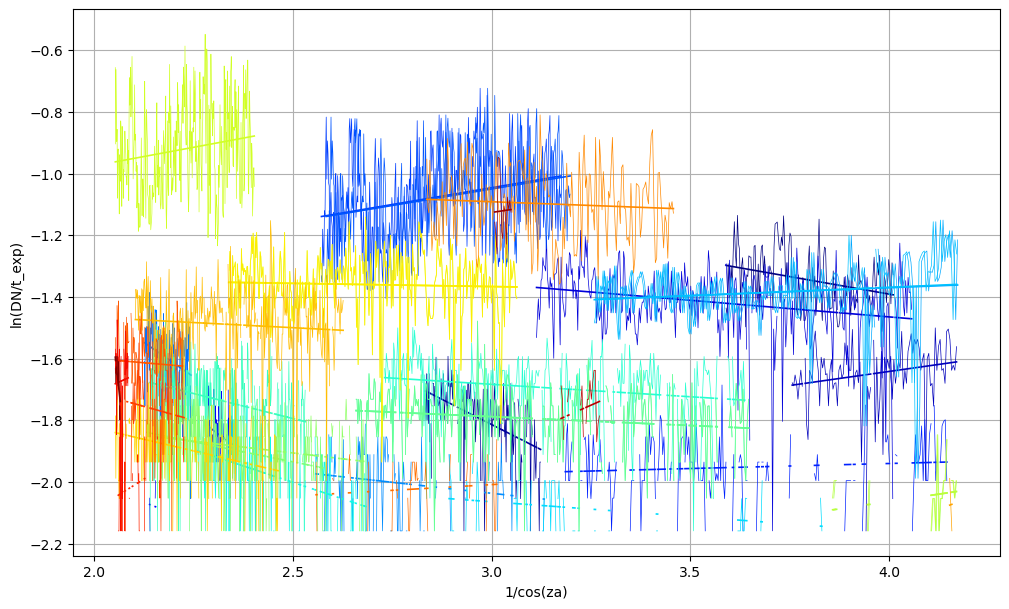

In [ ]:
# pia(id_arr, plot_val=4)
langley_plot(id_arr) 

5. Make a single langley plot for sanity...

/var/folders/hx/hcs55bp10f5fdvcmjf0rmf4r0000gn/T/ipykernel_44438/1503244194.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  els = id_arr.applymap(lambda x: x[3] if isinstance(x, tuple) else np.nan)[star_id]
/var/folders/hx/hcs55bp10f5fdvcmjf0rmf4r0000gn/T/ipykernel_44438/1503244194.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dns = id_arr.applymap(lambda x: x[1] if isinstance(x, tuple) else np.nan)[star_id]


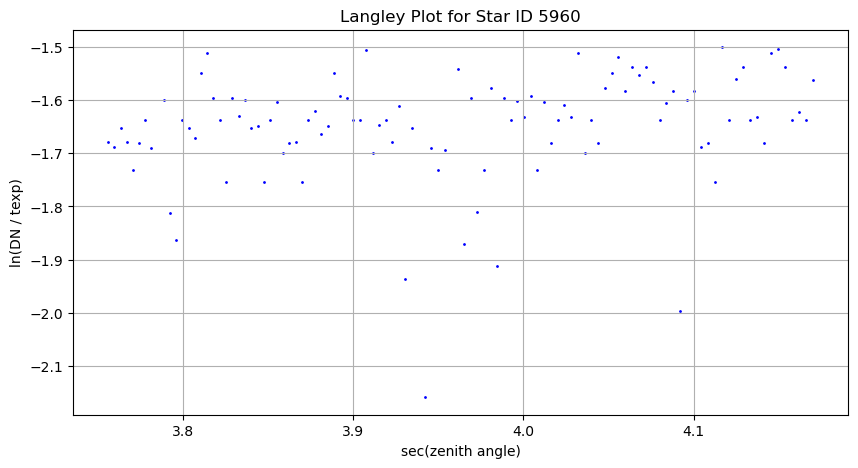

In [57]:
# Elevation angle and DN for select star
star_id = 5960
els = id_arr.applymap(lambda x: x[3] if isinstance(x, tuple) else np.nan)[star_id]
dns = id_arr.applymap(lambda x: x[1] if isinstance(x, tuple) else np.nan)[star_id]
texp = 10000.0 / 1000.0 # 10 ms exposure time

zenith = np.deg2rad(90 - els)
x = 1 / np.cos(zenith) 
y = np.log(dns / texp) 

plt.figure(figsize=(10, 5))
plt.scatter(x, y, s=1, c='blue')
plt.title(f"Langley Plot for Star ID {star_id}")
plt.xlabel("sec(zenith angle)")
plt.ylabel("ln(DN / texp)")
plt.grid()
plt.show()